In [10]:
# Install required Packages


%pip install pandas numpy matplotlib seaborn scikit-learn --quiet
%pip install fsspec==2023.9.2

print("✅ Packages installed successfully!")


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
✅ Packages installed successfully!


In [11]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datasets import load_dataset

#Set some other useful settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print('Libraries imported successfully!')


Libraries imported successfully!


In [12]:
#SVAMP Dataset Loader
loader = load_dataset("ChilleD/SVAMP")

train_data = loader["train"]
test_data = loader["test"]

In [13]:
datasets=loader #Use the same 'datasets' name

print(train_data)
print(train_data.shape)
print(test_data)
print(test_data.shape)

#Look at some examples of each variable
for v in ['ID','Body','Question','Equation','Answer','Type',"question_concat"]:
  print(f'Test {v} examples: {test_data[v][0:5]}')
  print(f'Training {v} examples: {train_data[v][0:5]}')

Dataset({
    features: ['ID', 'Body', 'Question', 'Equation', 'Answer', 'Type', 'question_concat'],
    num_rows: 700
})
(700, 7)
Dataset({
    features: ['ID', 'Body', 'Question', 'Equation', 'Answer', 'Type', 'question_concat'],
    num_rows: 300
})
(300, 7)
Test ID examples: ['chal-736', 'chal-162', 'chal-349', 'chal-390', 'chal-781']
Training ID examples: ['chal-777', 'chal-508', 'chal-896', 'chal-923', 'chal-34']
Test Body examples: ['Winter is almost here and most animals are migrating to warmer countries. There are 41 bird families living near the mountain. If 35 bird families flew away to asia and 62 bird families flew away to africa', 'Paige raised 7 goldfish and 12 catfish in the pond but stray cats loved eating them. Now she has 15 left.', "Marco and his dad went strawberry picking. Together they collected strawberries that weighed 22 pounds. On the way back Marco ' dad found 30 more pounds of strawberries. Marco's strawberries now weighed 36 pounds.", 'Debby bought 200 wat

Distribution of Problem Text Length (Test vs Training data)


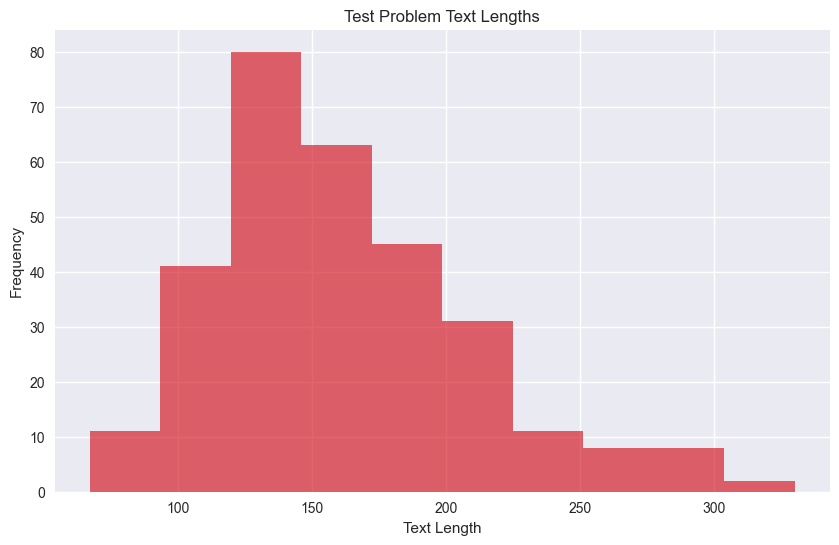

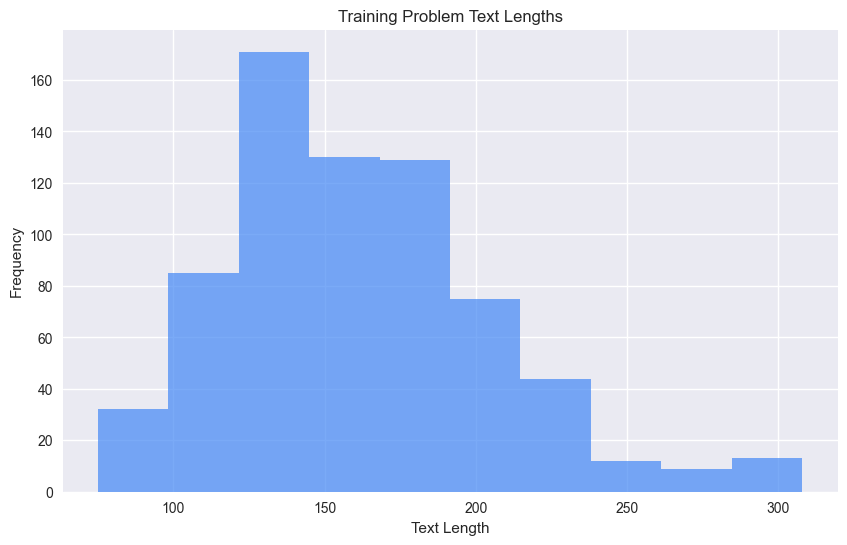

In [14]:
print('Distribution of Problem Text Length (Test vs Training data)')
test_problem_lengths=[]
train_problem_lengths=[]

##For the length of the problem, I am considering both the length of the body, and that of the actual question
for i in range(0,len(test_data['Body'])):
  test_problem_lengths.append(len(test_data['Body'][i])+len(test_data['Question'][i]))
for i in range(0,len(train_data['Body'])):
  train_problem_lengths.append(len(train_data['Body'][i])+len(train_data['Question'][i]))

#Test Lengths
plt.figure(figsize=(10, 6))
plt.hist(test_problem_lengths, bins=10, alpha=0.7,color='#d6222e')
plt.title('Test Problem Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()
#Training lengths

plt.figure(figsize=(10, 6))
plt.hist(train_problem_lengths, bins=10, alpha=0.7,color='#4287f5')
plt.title('Training Problem Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

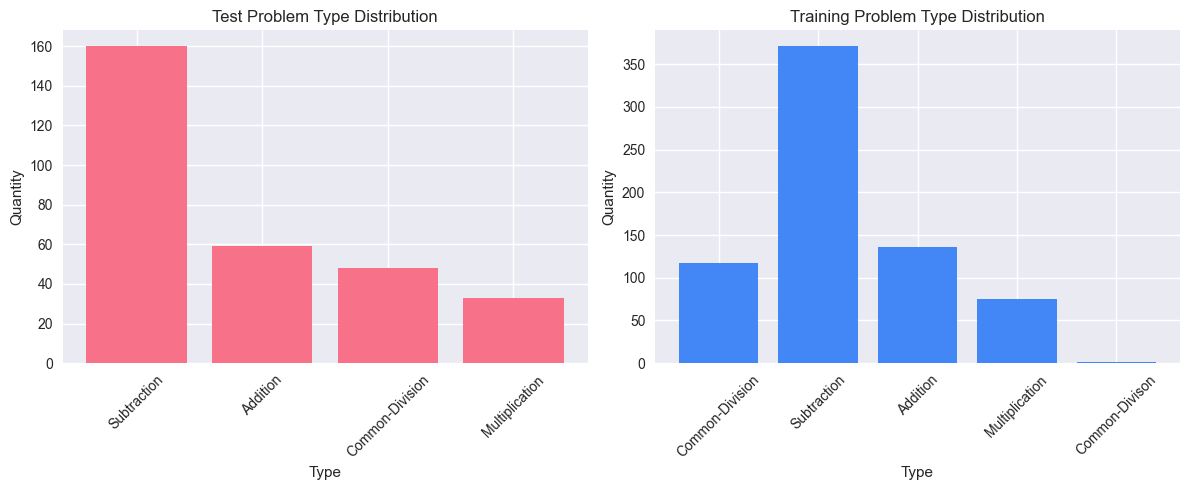

In [15]:
# Analyze Problem Type distribution

#Use the Counter from the collections, This makes it easier to get the amount of each type for creation of the bar plot
from collections import Counter

test_types=Counter(test_data["Type"])
train_types=Counter(train_data["Type"])
test_type=list(test_types.keys())
test_type_quantities=list(test_types.values())
train_type=list(train_types.keys())
train_type_quantities=list(train_types.values())

plt.figure(figsize=(12, 5))

#Testing Data
plt.subplot(1, 2, 1)
plt.bar(test_type,test_type_quantities)
plt.title('Test Problem Type Distribution')
plt.xlabel('Type')
plt.ylabel('Quantity')
plt.xticks(rotation=45)

#Training Data
plt.subplot(1, 2, 2)
plt.bar(train_type,train_type_quantities,color='#4287f5')
plt.title('Training Problem Type Distribution')
plt.xlabel('Type')
plt.ylabel('Quantity')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [16]:
#Look at the type of each individual problem
for v in ['Type']:
  print(f'Test {v} examples: {test_data[v]}')
  print(f'Training {v} examples: {train_data[v]}')

Test Type examples: Column(['Subtraction', 'Subtraction', 'Addition', 'Common-Division', 'Subtraction'])
Training Type examples: Column(['Common-Division', 'Subtraction', 'Common-Division', 'Common-Division', 'Subtraction'])


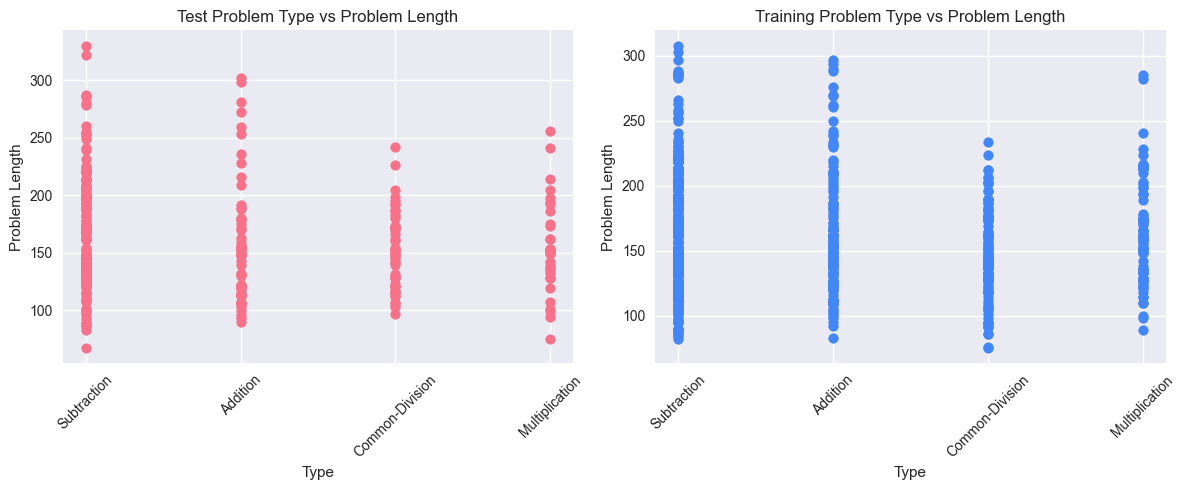

In [17]:
#Check the length of a problem (body and question) vs its type

#Store the type of the problem as a number to enable plotting
test_type_id=[]
train_type_id=[]

tp=["Subtraction","Addition","Common-Division","Multiplication","Common-Divison"]
for i in test_data["Type"]:
  test_type_id.append(tp.index(i))
for i in train_data["Type"]:
  if i=="Common-Divison": #"Divison" is likely a misspelling of "Division", so fix it here
    train_type_id.append(tp.index("Common-Division"))
  else:
    train_type_id.append(tp.index(i))


plt.figure(figsize=(12, 5))

#Testing Data
plt.subplot(1, 2, 1)
plt.scatter(test_type_id,test_problem_lengths)
plt.title('Test Problem Type vs Problem Length')
plt.xlabel('Type')
plt.ylabel('Problem Length')
plt.xticks(rotation=45)
plt.xticks([0,1,2,3],tp[0:4])

#Training Data
plt.subplot(1, 2, 2)
plt.scatter(train_type_id,train_problem_lengths,color='#4287f5')
plt.title('Training Problem Type vs Problem Length')
plt.xlabel('Type')
plt.ylabel('Problem Length')
plt.xticks(rotation=45)
plt.xticks([0,1,2,3],tp[0:4])
plt.tight_layout()
plt.show()

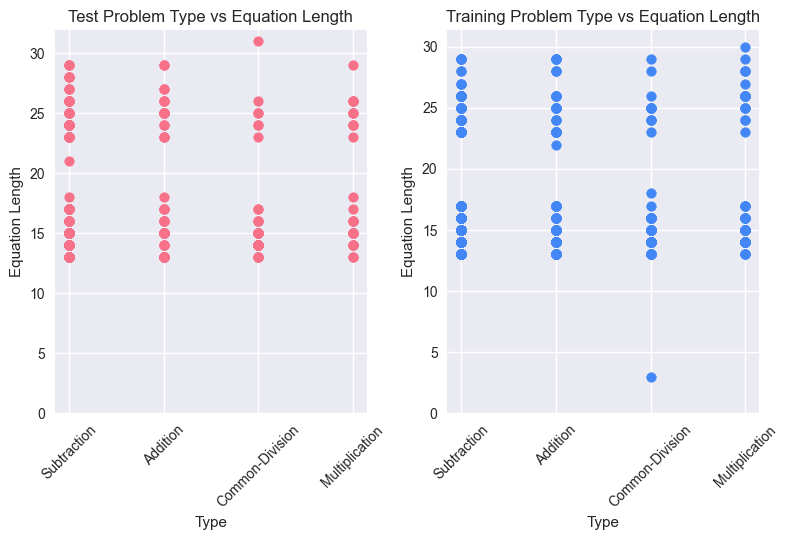

In [18]:
##Check the length of the Equation vs its type
test_equation_lengths=[]
train_equation_lengths=[]

for i in range(0,len(test_data['Equation'])):
  test_equation_lengths.append(len(test_data['Equation'][i]))
for i in range(0,len(train_data['Equation'])):
  train_equation_lengths.append(len(train_data['Equation'][i]))

#Testing Data
plt.subplot(1, 2, 1)
plt.scatter(test_type_id,test_equation_lengths)
plt.title('Test Problem Type vs Equation Length')
plt.xlabel('Type')
plt.ylabel('Equation Length')
plt.xticks(rotation=45)

#Put problem types on X axis, ensure ticks are spaced properly
plt.xticks([0,1,2,3],tp[0:4])
plt.yticks([0,5,10,15,20,25,30])

#Training Data
plt.subplot(1, 2, 2)
plt.scatter(train_type_id,train_equation_lengths,color='#4287f5')
plt.title('Training Problem Type vs Equation Length')
plt.xlabel('Type')
plt.ylabel('Equation Length')
plt.xticks(rotation=45)

#Put problem types on X axis, ensure ticks are spaced properly
plt.xticks([0,1,2,3],tp[0:4])
plt.yticks([0,5,10,15,20,25,30])
plt.tight_layout()
plt.show()